# Sure-Things Decomposition for B2B Intent Scores

This notebook demonstrates the core diagnostic for the GTM causal evaluation project: high intent can identify accounts that are likely to convert, but that does not mean intent-triggered outreach created those conversions.

The synthetic data has planted uplift segments for validation only:

- `sure_thing`: the highest baseline conversion rate under business-as-usual/control, which outreach barely moves.
- `persuadable`: incremental outreach increases conversion probability.
- `lost_cause`: low conversion either way.
- `anti_persuadable`: outreach can reduce conversion probability.

The segments are probabilistic, not deterministic. A `sure_thing` is not certain to convert; it has the highest planted baseline rate of any segment, and outreach adds little to it. Section 2 prints the planted rates per segment.

Modeling guardrail: hidden ground-truth columns are not used as model inputs. They appear only in validation sections.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src/generate_synthetic_crm.py").exists():
            return candidate
    raise FileNotFoundError("Could not find src/generate_synthetic_crm.py in this folder or any parent")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())

sys.path.insert(0, str(PROJECT_ROOT / "src"))
from generate_synthetic_crm import generate_synthetic_crm

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

SEGMENT_ORDER = ["sure_thing", "persuadable", "lost_cause", "anti_persuadable"]
BUCKET_ORDER = ["likely_sure_thing", "plausible_persuadable", "low_priority"]

## 1. Load or Generate Synthetic Data

The generated CSV is local-only by default. If it does not exist, the notebook recreates it from `src/generate_synthetic_crm.py`.

In [2]:
data_path = PROJECT_ROOT / "data/generated/synthetic_crm.csv"

if data_path.exists():
    df = pd.read_csv(data_path, keep_default_na=False, na_values=[""])
else:
    data_path.parent.mkdir(parents=True, exist_ok=True)
    df = generate_synthetic_crm(n_accounts=20_000, seed=42)
    df.to_csv(data_path, index=False)

print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns):,}")
df.head()

Rows: 20,000
Columns: 29


,account_id,campaign_id,segment_true,company_size,annual_revenue_m,industry,region,tech_fit_score,firmographic_fit_score,prior_website_visits_90d,prior_email_engagement_90d,prior_sales_touches_180d,prior_opportunity,crm_stage_pre,intent_score,high_intent,intent_topic_count,linkedin_engagement_score,review_site_activity_score,treated,outreach_delay_days,outreach_channel,sdr_touches_14d,meeting_booked_60d,opportunity_created_90d,pipeline_created_90d,control_meeting_prob_true,treated_meeting_prob_true,treatment_effect_true
0,acct_000001,intent_window_2026q3,lost_cause,199,60.78,other,AMER,0.1346,0.0809,0,0,0,False,unqualified,37.4,False,0,0.0000,0.0164,False,-1,none,0,False,False,0.0,0.00200,0.00400,0.002
1,acct_000002,intent_window_2026q3,persuadable,337,44.72,healthcare,AMER,0.4998,0.5526,8,2,5,False,marketing_qualified,77.9,False,2,0.4397,0.5728,True,1,linkedin,4,False,False,0.0,0.04389,0.12389,0.080
2,acct_000003,intent_window_2026q3,lost_cause,64,5.86,fintech,AMER,0.4127,0.0902,7,5,0,False,unqualified,67.3,False,0,0.2250,0.1622,False,-1,none,0,False,False,0.0,0.01228,0.01428,0.002
3,acct_000004,intent_window_2026q3,lost_cause,440,58.44,healthcare,EMEA,0.3306,0.5450,8,3,3,False,marketing_qualified,69.0,False,0,0.3500,0.1222,True,6,sequence,3,False,False,0.0,0.02719,0.02919,0.002
4,acct_000005,intent_window_2026q3,sure_thing,1207,588.03,marketplace,AMER,0.6412,0.8055,16,3,2,False,open_opportunity,86.1,True,2,0.7938,0.4548,False,-1,none,0,False,True,26000.0,0.19009,0.20009,0.010


## 2. Validate The Planted Failure Mode

This first section uses planted segment labels for validation context. In real data, these labels would not exist.

In [3]:
intent_x_segment_counts = pd.crosstab(df["high_intent"], df["segment_true"]).rename(index={False: "low_intent", True: "high_intent"})[SEGMENT_ORDER]
intent_x_segment_pct = intent_x_segment_counts.div(intent_x_segment_counts.sum(axis=1), axis=0).mul(100).round(1)
segment_marked_high_intent = intent_x_segment_counts.div(intent_x_segment_counts.sum(axis=0), axis=1).mul(100).round(1)

print("Counts: intent status by planted uplift segment")
display(intent_x_segment_counts)

print("Row percentages")
display(intent_x_segment_pct)

print("Share of each planted segment marked high intent")
display(segment_marked_high_intent.loc[["high_intent"]])

Counts: intent status by planted uplift segment


segment_true,sure_thing,persuadable,lost_cause,anti_persuadable
high_intent,,,,
low_intent,844,1713,7755,1458
high_intent,4201,2240,1256,533


Row percentages


segment_true,sure_thing,persuadable,lost_cause,anti_persuadable
high_intent,,,,
low_intent,7.2,14.6,65.9,12.4
high_intent,51.0,27.2,15.3,6.5


Share of each planted segment marked high intent


segment_true,sure_thing,persuadable,lost_cause,anti_persuadable
high_intent,,,,
high_intent,83.3,56.7,13.9,26.8


In [4]:
planted_rates = (
    df.groupby("segment_true", observed=True)[
        ["control_meeting_prob_true", "treated_meeting_prob_true", "treatment_effect_true"]
    ]
    .mean()
    .mul(100)
    .reindex(SEGMENT_ORDER)
    .rename(columns={
        "control_meeting_prob_true": "control_rate_pct",
        "treated_meeting_prob_true": "treated_rate_pct",
        "treatment_effect_true": "true_lift_pp",
    })
)
display(planted_rates.round(1))


,control_rate_pct,treated_rate_pct,true_lift_pp
segment_true,,,
sure_thing,19.3,20.3,1.0
persuadable,5.0,13.0,8.0
lost_cause,1.6,1.8,0.2
anti_persuadable,5.9,4.4,-1.5


In [5]:
naive_summary = (
    df.groupby(["high_intent", "treated"], observed=True)
    .agg(
        accounts=("account_id", "count"),
        observed_meeting_rate=("meeting_booked_60d", "mean"),
        true_control_rate=("control_meeting_prob_true", "mean"),
        true_treated_rate=("treated_meeting_prob_true", "mean"),
        true_lift_pp=("treatment_effect_true", lambda s: 100 * s.mean()),
    )
    .reset_index()
)
naive_summary["observed_meeting_rate"] = (100 * naive_summary["observed_meeting_rate"]).round(2)
naive_summary["true_control_rate"] = (100 * naive_summary["true_control_rate"]).round(2)
naive_summary["true_treated_rate"] = (100 * naive_summary["true_treated_rate"]).round(2)
naive_summary["true_lift_pp"] = naive_summary["true_lift_pp"].round(2)

naive_summary

,high_intent,treated,accounts,observed_meeting_rate,true_control_rate,true_treated_rate,true_lift_pp
0,False,False,9417,3.13,3.28,4.30,1.02
1,False,True,2353,7.52,5.98,7.81,1.83
2,True,False,2549,9.93,9.31,11.86,2.56
3,True,True,5681,15.81,13.11,15.76,2.65


Naive intent and treatment summaries look good: high-intent accounts convert more often. The causal question is whether the outreach created those meetings or mostly harvested baseline demand.

## 3. Fit A Baseline Propensity Model

Train on untreated/control accounts using only pre-signal features. The model estimates business-as-usual meeting propensity before using the intent signal.

Excluded validation-only columns:

- `segment_true`
- `control_meeting_prob_true`
- `treated_meeting_prob_true`
- `treatment_effect_true`

In [6]:
pre_signal_features = [
    "company_size",
    "annual_revenue_m",
    "industry",
    "region",
    "tech_fit_score",
    "firmographic_fit_score",
    "prior_website_visits_90d",
    "prior_email_engagement_90d",
    "prior_sales_touches_180d",
    "prior_opportunity",
    "crm_stage_pre",
]

validation_only = {"segment_true", "control_meeting_prob_true", "treated_meeting_prob_true", "treatment_effect_true"}
assert validation_only.isdisjoint(pre_signal_features)
assert "intent_score" not in pre_signal_features
assert "high_intent" not in pre_signal_features
assert "treated" not in pre_signal_features

categorical_features = ["industry", "region", "crm_stage_pre"]
numeric_features = [c for c in pre_signal_features if c not in categorical_features]

control_df = df.loc[~df["treated"]].copy()

baseline_model = Pipeline(
    steps=[
        (
            "preprocess",
            ColumnTransformer(
                transformers=[
                    ("num", StandardScaler(), numeric_features),
                    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
                ]
            ),
        ),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ]
)

baseline_model.fit(control_df[pre_signal_features], control_df["meeting_booked_60d"])
df["baseline_propensity_hat"] = baseline_model.predict_proba(df[pre_signal_features])[:, 1]

control_auc = roc_auc_score(
    control_df["meeting_booked_60d"],
    baseline_model.predict_proba(control_df[pre_signal_features])[:, 1],
)

print(f"Control-sample baseline propensity AUC: {control_auc:.3f}")
df[["baseline_propensity_hat", "control_meeting_prob_true", "intent_score", "high_intent"]].describe().round(3)

Control-sample baseline propensity AUC: 0.768


,baseline_propensity_hat,control_meeting_prob_true,intent_score
count,20000.000,20000.000,20000.000
mean,0.496,0.072,71.286
std,0.238,0.073,19.310
min,0.070,0.002,7.400
25%,0.275,0.016,58.100
50%,0.463,0.045,75.100
75%,0.721,0.171,87.500
max,0.965,0.214,99.500


The model is intentionally simple. The goal is not the best possible predictive model; the goal is to separate high-intent accounts that already looked likely to convert from accounts where intent may identify a more persuadable opportunity.

Two caveats matter. First, this baseline model is trained on untreated accounts, so a real CRM application would need to worry about treatment-selection bias in the untreated sample. Second, the model uses class weighting, so `baseline_propensity_hat` should be read as a ranking score rather than a calibrated probability.

### Synthetic Rank Validation

Because this is synthetic data, we can directly check whether the rank-order diagnostic survives the biased untreated training sample. This validation uses planted ground truth and would not be available in production.

In [7]:
rank_validation = pd.Series(
    {
        "spearman_all_accounts": df["baseline_propensity_hat"].corr(df["control_meeting_prob_true"], method="spearman"),
        "spearman_high_intent": df.loc[df["high_intent"], "baseline_propensity_hat"].corr(
            df.loc[df["high_intent"], "control_meeting_prob_true"],
            method="spearman",
        ),
    }
).round(3)

rank_validation

spearman_all_accounts    0.951
spearman_high_intent     0.899
dtype: float64

## 4. Decompose High-Intent Accounts

Use the baseline propensity score to create diagnostic buckets among high-intent accounts:

- `likely_sure_thing`: high intent and top-20% baseline propensity.
- `plausible_persuadable`: high intent and middle baseline propensity.
- `low_priority`: high intent and low baseline propensity.

These are diagnostic labels, not proven individual causal labels.

In [8]:
q40, q80 = df["baseline_propensity_hat"].quantile([0.40, 0.80])

df["diagnostic_bucket"] = "not_high_intent"
high_intent_mask = df["high_intent"]

df.loc[high_intent_mask & (df["baseline_propensity_hat"] >= q80), "diagnostic_bucket"] = "likely_sure_thing"
df.loc[
    high_intent_mask & (df["baseline_propensity_hat"] < q80) & (df["baseline_propensity_hat"] >= q40),
    "diagnostic_bucket",
] = "plausible_persuadable"
df.loc[high_intent_mask & (df["baseline_propensity_hat"] < q40), "diagnostic_bucket"] = "low_priority"

bucket_summary = (
    df.loc[high_intent_mask]
    .groupby("diagnostic_bucket", observed=True)
    .agg(
        accounts=("account_id", "count"),
        avg_intent_score=("intent_score", "mean"),
        avg_baseline_propensity_hat=("baseline_propensity_hat", "mean"),
        observed_meeting_rate=("meeting_booked_60d", "mean"),
        true_control_rate=("control_meeting_prob_true", "mean"),
        true_lift_pp=("treatment_effect_true", lambda s: 100 * s.mean()),
    )
    .reindex(BUCKET_ORDER)
)

bucket_summary["avg_intent_score"] = bucket_summary["avg_intent_score"].round(1)
bucket_summary["avg_baseline_propensity_hat"] = bucket_summary["avg_baseline_propensity_hat"].round(3)
bucket_summary["observed_meeting_rate"] = (100 * bucket_summary["observed_meeting_rate"]).round(2)
bucket_summary["true_control_rate"] = (100 * bucket_summary["true_control_rate"]).round(2)
bucket_summary["true_lift_pp"] = bucket_summary["true_lift_pp"].round(2)

bucket_summary

,accounts,avg_intent_score,avg_baseline_propensity_hat,observed_meeting_rate,true_control_rate,true_lift_pp
diagnostic_bucket,,,,,,
likely_sure_thing,3374,91.2,0.835,20.42,18.32,1.65
plausible_persuadable,3854,88.4,0.616,11.44,8.99,4.10
low_priority,1002,85.6,0.269,2.10,1.75,0.20


## 5. Validate Buckets Against Planted Segments

This is the validation section. It uses hidden synthetic labels only after the diagnostic buckets have been assigned.

In [9]:
bucket_x_segment_counts = pd.crosstab(
    df.loc[high_intent_mask, "diagnostic_bucket"],
    df.loc[high_intent_mask, "segment_true"],
).reindex(BUCKET_ORDER)[SEGMENT_ORDER]

bucket_x_segment_pct = bucket_x_segment_counts.div(bucket_x_segment_counts.sum(axis=1), axis=0).mul(100).round(1)

print("Counts: diagnostic bucket by planted segment")
display(bucket_x_segment_counts)

print("Row percentages")
display(bucket_x_segment_pct)

Counts: diagnostic bucket by planted segment


segment_true,sure_thing,persuadable,lost_cause,anti_persuadable
diagnostic_bucket,,,,
likely_sure_thing,3053,317,0,4
plausible_persuadable,1148,1913,307,486
low_priority,0,10,949,43


Row percentages


segment_true,sure_thing,persuadable,lost_cause,anti_persuadable
diagnostic_bucket,,,,
likely_sure_thing,90.5,9.4,0.0,0.1
plausible_persuadable,29.8,49.6,8.0,12.6
low_priority,0.0,1.0,94.7,4.3


Expected result: the `likely_sure_thing` bucket should be enriched for `sure_thing`, and the `plausible_persuadable` bucket should have the highest concentration of `persuadable` accounts.

## 6. ROI and Waste By Diagnostic Bucket

The ROI calculation values incremental meetings only. Baseline meetings are expected meetings that would have happened under control/business-as-usual.

In this synthetic validation, ROI uses planted ground-truth control and treatment probabilities. In real data, these quantities would need to come from a randomized holdout, rollout design, or another credible causal design.

In [10]:
COST_PER_TOUCH = 25
VALUE_PER_INCREMENTAL_MEETING = 10_000

def roi_table(data: pd.DataFrame, group_col: str) -> pd.DataFrame:
    treated = data.loc[data["treated"]].copy()
    treated["outreach_cost"] = treated["sdr_touches_14d"] * COST_PER_TOUCH
    treated["expected_baseline_meetings"] = treated["control_meeting_prob_true"]
    treated["expected_incremental_meetings"] = treated["treatment_effect_true"]
    treated["expected_total_treated_meetings"] = treated["treated_meeting_prob_true"]
    treated["incremental_revenue"] = treated["expected_incremental_meetings"] * VALUE_PER_INCREMENTAL_MEETING
    treated["profit"] = treated["incremental_revenue"] - treated["outreach_cost"]

    out = treated.groupby(group_col, observed=True).agg(
        accounts=("account_id", "count"),
        touches=("sdr_touches_14d", "sum"),
        spend=("outreach_cost", "sum"),
        baseline_meetings=("expected_baseline_meetings", "sum"),
        incremental_meetings=("expected_incremental_meetings", "sum"),
        total_expected_meetings=("expected_total_treated_meetings", "sum"),
        incremental_revenue=("incremental_revenue", "sum"),
        profit=("profit", "sum"),
    )
    out["roi_pct"] = 100 * out["profit"] / out["spend"]
    return out

diagnostic_roi = roi_table(df.loc[df["high_intent"]], "diagnostic_bucket").reindex(BUCKET_ORDER)
display(diagnostic_roi.round(1))

,accounts,touches,spend,baseline_meetings,incremental_meetings,total_expected_meetings,incremental_revenue,profit,roi_pct
diagnostic_bucket,,,,,,,,,
likely_sure_thing,2703,13677,341925,495.5,44.4,539.8,443600.0,101675.0,29.7
plausible_persuadable,2553,12876,321900,241.5,105.4,346.8,1053550.0,731650.0,227.3
low_priority,425,2142,53550,7.7,0.9,8.6,8830.0,-44720.0,-83.5


In [11]:
oracle_segment_roi = roi_table(df, "segment_true").reindex(SEGMENT_ORDER)
display(oracle_segment_roi.round(1))

,accounts,touches,spend,baseline_meetings,incremental_meetings,total_expected_meetings,incremental_revenue,profit,roi_pct
segment_true,,,,,,,,,
sure_thing,3683,17781,444525,711.3,36.8,748.1,368300.0,-76225.0,-17.1
persuadable,2044,9297,232425,104.7,163.5,268.2,1635200.0,1402775.0,603.5
lost_cause,1644,6158,153950,29.0,3.3,32.3,32880.0,-121070.0,-78.6
anti_persuadable,663,2678,66950,40.3,-9.9,30.4,-99450.0,-166400.0,-248.5


The segment-level table is an oracle validation view. In real data, the equivalent segment labels and true treatment effects would need to be estimated from randomized holdouts, staggered rollouts, or another credible causal design.

## 6b. Policy-Level Economics

The bucket table above covers high-intent accounts only. Any statement about "the ROI of the intent program" therefore needs the program defined first.

Treated accounts fall into two groups that are easy to pool by accident:

- accounts the intent signal flagged, which the program is actually about
- accounts contacted anyway, with no intent trigger

Pooling them produces a single ROI number that describes neither group.


In [12]:
def policy_economics(data: pd.DataFrame, label: str) -> dict:
    spend = data["sdr_touches_14d"].sum() * COST_PER_TOUCH
    incremental = data["treatment_effect_true"].sum()
    total_treated_meetings = data["treated_meeting_prob_true"].sum()
    return {
        "policy": label,
        "accounts": len(data),
        "spend": spend,
        "baseline_meetings": data["control_meeting_prob_true"].sum(),
        "incremental_meetings": incremental,
        "incremental_share_pct": 100 * incremental / total_treated_meetings,
        "roi_pct": 100 * (incremental * VALUE_PER_INCREMENTAL_MEETING - spend) / spend,
    }


treated_all = df.loc[df["treated"]]

policy_comparison = pd.DataFrame(
    [
        policy_economics(treated_all, "all outreach (pooled)"),
        policy_economics(treated_all.loc[treated_all["high_intent"]], "intent-triggered"),
        policy_economics(treated_all.loc[~treated_all["high_intent"]], "not intent-triggered"),
    ]
).set_index("policy")

display(policy_comparison.round(1))

,accounts,spend,baseline_meetings,incremental_meetings,incremental_share_pct,roi_pct
policy,,,,,,
all outreach (pooled),8034,897850,885.3,193.7,18.0,115.7
intent-triggered,5681,717375,744.7,150.6,16.8,109.9
not intent-triggered,2353,180475,140.6,43.1,23.5,138.8


The pooled row is the one worth distrusting. In this synthetic world the accounts the intent score did **not** flag return a higher ROI than the accounts it did, so the pooled number flatters the intent program by mixing in outreach the program never triggered.

This is the same propensity-versus-uplift confusion the article is about, appearing one level up in the reporting rather than in the model.


Inside the intent-triggered program, how much spend went to accounts outreach could not help, and what did the anti-persuadable group cost? Both use planted ground truth.


In [13]:
intent_triggered = treated_all.loc[treated_all["high_intent"]]
it_spend = intent_triggered["sdr_touches_14d"].sum() * COST_PER_TOUCH

non_persuadable = intent_triggered.loc[intent_triggered["segment_true"] != "persuadable"]
non_persuadable_spend = non_persuadable["sdr_touches_14d"].sum() * COST_PER_TOUCH

anti = intent_triggered.loc[intent_triggered["segment_true"] == "anti_persuadable"]

print(f"intent-triggered spend:            ${it_spend:,.0f}")
print(f"spend on non-persuadables:         ${non_persuadable_spend:,.0f}")
print(f"share of that spend:               {100 * non_persuadable_spend / it_spend:.1f}%")
print()
print(f"anti-persuadable accounts:         {len(anti):,}")
print(f"anti-persuadable spend:            ${anti['sdr_touches_14d'].sum() * COST_PER_TOUCH:,.0f}")
print(f"incremental meetings (planted):    {anti['treatment_effect_true'].sum():.1f}")


intent-triggered spend:            $717,375
spend on non-persuadables:         $524,725
share of that spend:               73.1%

anti-persuadable accounts:         326
anti-persuadable spend:            $40,300
incremental meetings (planted):    -4.9


## 6c. Oracle Uplift Benchmark

This section computes what perfect uplift targeting would achieve. It is an upper bound, not a deployable policy, and it rests on three assumptions that are stated here because they change the answer:

1. **Cost.** Contacting an account costs the average observed cost per treated account. Untreated accounts have `sdr_touches_14d == 0`, so some per-account cost has to be assumed for any account the real policy never contacted.
2. **Eligible pool.** The oracle selects from the entire account base, not just high-intent accounts. It is therefore a wider comparison than "better targeting within the intent list".
3. **Information.** It ranks on `treatment_effect_true`, which is planted ground truth and is never observable in real data.


In [14]:
actual_spend = treated_all["sdr_touches_14d"].sum() * COST_PER_TOUCH
cost_per_contacted_account = actual_spend / len(treated_all)

print(f"assumed cost per contacted account: ${cost_per_contacted_account:,.2f}")


def oracle_policy(selected: pd.DataFrame, label: str) -> dict:
    spend = cost_per_contacted_account * len(selected)
    incremental = selected["treatment_effect_true"].sum()
    profit = incremental * VALUE_PER_INCREMENTAL_MEETING - spend
    return {
        "policy": label,
        "accounts": len(selected),
        "spend": spend,
        "incremental_meetings": incremental,
        "profit": profit,
        "roi_pct": 100 * profit / spend,
    }


# Same contact volume as the real policy, but ranked by true uplift.
oracle_same_volume = df.nlargest(len(treated_all), "treatment_effect_true")

# Contact only accounts whose expected incremental value exceeds the contact cost.
oracle_profitable = df.loc[
    df["treatment_effect_true"] * VALUE_PER_INCREMENTAL_MEETING > cost_per_contacted_account
]

oracle_comparison = pd.DataFrame(
    [
        oracle_policy(treated_all, "actual policy (all outreach)"),
        oracle_policy(oracle_same_volume, "oracle uplift, same volume"),
        oracle_policy(oracle_profitable, "oracle uplift, profitable only"),
    ]
).set_index("policy")

display(oracle_comparison.round(1))

assumed cost per contacted account: $111.76


,accounts,spend,incremental_meetings,profit,roi_pct
policy,,,,,
actual policy (all outreach),8034,897850.0,193.7,1039080.0,115.7
"oracle uplift, same volume",8034,897850.0,357.0,2672650.0,297.7
"oracle uplift, profitable only",3953,441772.6,316.2,2720627.4,615.8


The gap between the first row and the other two is the economic cost of ranking accounts by propensity instead of by incremental response. It is not a product claim, and no part of it is reachable without either ground truth or a credible causal design.


## 7. Headline Chart

This chart shows the practical diagnostic: high-intent accounts can be split into buckets with very different planted composition and ROI.

Both panels are validation views. The left panel uses synthetic planted segments, and the right panel uses planted ground-truth treatment effects to calculate incremental ROI. In a real deployment, this ROI panel would require holdout or rollout-based lift estimates.

Saved figures/generated/headline_diagnostic_buckets.png


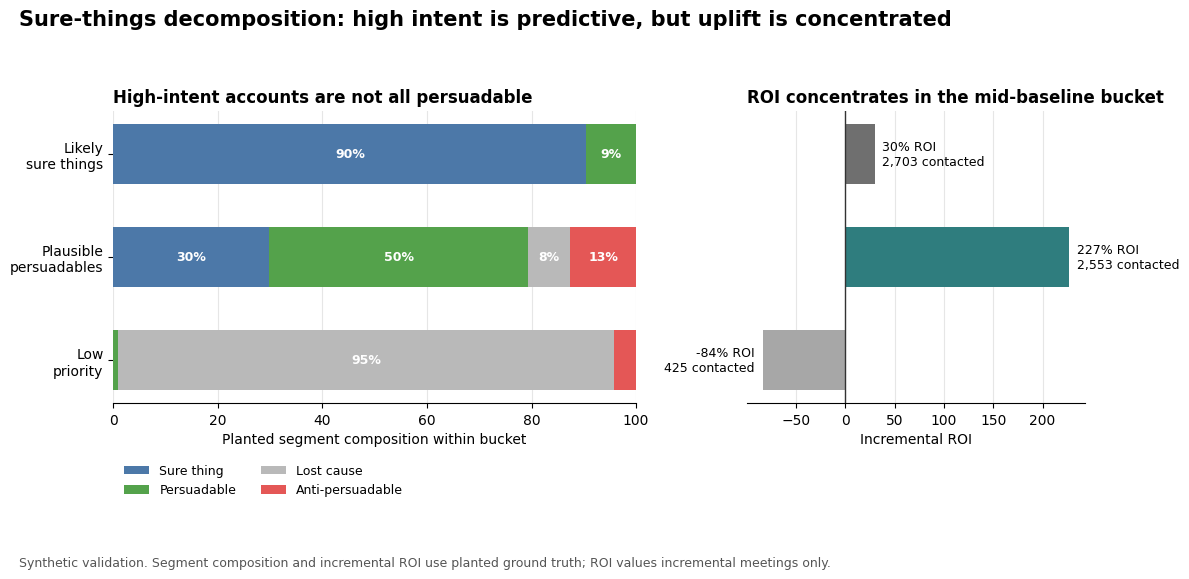

In [15]:
import os

os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".matplotlib-cache"))
import matplotlib.pyplot as plt

figure_dir = PROJECT_ROOT / "figures/generated"
figure_dir.mkdir(parents=True, exist_ok=True)

bucket_labels = {
    "likely_sure_thing": "Likely\nsure things",
    "plausible_persuadable": "Plausible\npersuadables",
    "low_priority": "Low\npriority",
}
segment_labels = {
    "sure_thing": "Sure thing",
    "persuadable": "Persuadable",
    "lost_cause": "Lost cause",
    "anti_persuadable": "Anti-persuadable",
}
segment_colors = {
    "sure_thing": "#4C78A8",
    "persuadable": "#54A24B",
    "lost_cause": "#B9B9B9",
    "anti_persuadable": "#E45756",
}

composition = bucket_x_segment_pct.reindex(BUCKET_ORDER)[SEGMENT_ORDER]
roi_values = diagnostic_roi.reindex(BUCKET_ORDER)["roi_pct"]
contacted_counts = diagnostic_roi.reindex(BUCKET_ORDER)["accounts"].astype(int)

fig, (ax_comp, ax_roi) = plt.subplots(
    ncols=2,
    figsize=(12, 5.8),
    gridspec_kw={"width_ratios": [1.55, 1.0]},
)

y = np.arange(len(BUCKET_ORDER))
left = np.zeros(len(BUCKET_ORDER))
for segment in SEGMENT_ORDER:
    values = composition[segment].to_numpy()
    ax_comp.barh(
        y,
        values,
        left=left,
        color=segment_colors[segment],
        label=segment_labels[segment],
        height=0.58,
    )
    for idx, value in enumerate(values):
        if value >= 8:
            ax_comp.text(left[idx] + value / 2, idx, f"{value:.0f}%", ha="center", va="center", color="white", fontsize=9, fontweight="bold")
    left += values

ax_comp.set_yticks(y)
ax_comp.set_yticklabels([bucket_labels[b] for b in BUCKET_ORDER])
ax_comp.invert_yaxis()
ax_comp.set_xlim(0, 100)
ax_comp.set_xlabel("Planted segment composition within bucket")
ax_comp.set_title("High-intent accounts are not all persuadable", loc="left", fontsize=12, fontweight="bold")
ax_comp.grid(axis="x", color="#E6E6E6", linewidth=0.8)
ax_comp.set_axisbelow(True)
ax_comp.legend(ncols=2, bbox_to_anchor=(0, -0.17), loc="upper left", frameon=False, fontsize=9)

roi_colors = ["#6F6F6F", "#2F7D7E", "#A7A7A7"]
ax_roi.barh(y, roi_values.to_numpy(), color=roi_colors, height=0.58)
ax_roi.axvline(0, color="#333333", linewidth=1)
for idx, value in enumerate(roi_values.to_numpy()):
    ha = "left" if value >= 0 else "right"
    offset = 8 if value >= 0 else -8
    ax_roi.text(value + offset, idx, f"{value:.0f}% ROI\n{contacted_counts.iloc[idx]:,} contacted", va="center", ha=ha, fontsize=9)

ax_roi.set_yticks([])
ax_roi.invert_yaxis()
ax_roi.set_xlabel("Incremental ROI")
ax_roi.set_title("ROI concentrates in the mid-baseline bucket", loc="left", fontsize=12, fontweight="bold")
ax_roi.grid(axis="x", color="#E6E6E6", linewidth=0.8)
ax_roi.set_axisbelow(True)

for ax in (ax_comp, ax_roi):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

fig.suptitle("Sure-things decomposition: high intent is predictive, but uplift is concentrated", x=0.02, ha="left", fontsize=15, fontweight="bold")
fig.text(0.02, 0.02, "Synthetic validation. Segment composition and incremental ROI use planted ground truth; ROI values incremental meetings only.", fontsize=9, color="#555555")
fig.tight_layout(rect=[0, 0.06, 1, 0.93])

headline_chart_path = figure_dir / "headline_diagnostic_buckets.png"
fig.savefig(headline_chart_path, dpi=180, bbox_inches="tight")
print(f"Saved {headline_chart_path.relative_to(PROJECT_ROOT)}")

## Takeaways

1. High intent is useful for prediction: high-intent accounts convert more often.
2. Prediction is not incrementality: much of high-intent conversion is baseline demand.
3. A pre-signal baseline propensity model can flag accounts that look like likely sure things.
4. The mid-baseline high-intent bucket is the better candidate pool for persuadables.
5. The diagnostic is not causal proof. Strong uplift claims still need randomized holdouts or credible rollout variation.